# 01 — Understand TMDB tables before designing an ontology

**Goal:** explain where each table comes from, what one row means, which things
should become graph resources, and why those resources are connected.

We read the **11 reference CSV tables in data/ref/**.
We do not read the old prepared tables in our project's data directory, use
Kaggle, call an API, or write CSV/RDF files. The values are saved source claims;
this notebook does not independently verify movie facts on the Web.

Read each explanation, run the cell below it, then read the interpretation.
Our questions are in [PROJECT_SCOPE.md](../docs/PROJECT_SCOPE.md) and
[queries/](../queries/README.md). The ontology and exporter come later.

**Route:** dataset overview → every field → one movie → keys and missingness →
genres → people and roles → dates and ratings → countries and languages →
graph model → constraints → how to produce the CSV tables → modeling decisions.

## 1. Four words to understand first

| Word | Meaning | Example |
|---|---|---|
| Class | A category of things | schema:Movie, schema:Person |
| Instance / individual | One particular thing in a category | The film identified by movie ID 969681 |
| Literal | A value, such as text, date, or number | A title, 145 minutes |
| Property | A named relationship | A movie has a director; a movie has a title |

An **object property** connects resources (movie → person).
A **datatype property** connects a resource to a literal (movie → date).
A **URI** identifies a resource. Our future https://example.org/movie/969681
is a development example, not a published page.

Movie is a class. A movie row becomes an instance. Its title is a literal.
**A CSV column is not automatically a class.** A relationship table usually
becomes edges rather than a new class.

OWL supplies logical meaning for classes and properties. RDF records facts
using them. We can sketch both now without implementing either.

In [19]:
from pathlib import Path
import json
import hashlib
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

# Locate our project from the workspace, project, or notebook directory.
candidates = [Path.cwd(), *Path.cwd().parents]
PROJECT = next((q for p in candidates for q in (p, p / 'semantic-web')
                if (q / 'data/ref/movies.csv').is_file()), None)
if PROJECT is None:
    raise FileNotFoundError('Cannot find semantic-web/data/ref/movies.csv; set DATA explicitly.')
DATA = PROJECT / 'data/ref'
TABLE_NAMES = ['movies', 'genres', 'companies', 'countries', 'languages',
               'movie_genres', 'movie_companies', 'movie_countries',
               'movie_languages', 'cast', 'crew']
# Read IDs as strings. The legitimate country code NA must not become a null.
tables = {n: pd.read_csv(DATA / f'{n}.csv', dtype=str, keep_default_na=False)
          for n in TABLE_NAMES}
movies, cast, crew = (tables[n] for n in ['movies', 'cast', 'crew'])
pd.set_option('display.max_colwidth', 85)
pd.set_option('display.max_columns', 12)
plt.rcParams.update({'figure.figsize': (9, 4), 'axes.spines.top': False,
                     'axes.spines.right': False, 'font.size': 10})
print('Input:', DATA)
print('Read-only exploration: no CSV or RDF files will be written.')

Input: c:\Users\admin\Programming\semanticweb\semantic-web\data\ref
Read-only exploration: no CSV or RDF files will be written.


## 2. What does one row mean?

The reference collector starts with popular-movie IDs, requests details and
credits, and splits nested lists into flat tables. It keeps up to ten cast
entries and all director credits. Five pages target approximately 100 movies.

- **Entity tables:** describe a movie, genre, company, country, or language once.
- **Relationship tables:** connect existing entities by their IDs.
- **Credit tables:** connect movies and people, including participation details.

There is no people.csv in the reference. People appear in cast/crew rows and
will be deduplicated by person ID when generating RDF.

In [20]:
row_meaning = {
 'movies': 'One movie, identified by TMDB movie ID',
 'genres': 'One genre, identified by genre ID',
 'companies': 'One production company, identified by company ID',
 'countries': 'One country, identified by country code',
 'languages': 'One language, identified by language code',
 'movie_genres': 'One movie–genre association',
 'movie_companies': 'One movie–company association',
 'movie_countries': 'One movie–production-country association',
 'movie_languages': 'One movie–spoken-language association',
 'cast': 'One retained acting credit (movie, person, character, order)',
 'crew': 'One retained director credit (movie, person, job)'}
display(pd.DataFrame([
 {'table': n, 'rows': len(d), 'columns': ', '.join(d.columns),
  'one row means': row_meaning[n]} for n, d in tables.items()]))
print(f'{len(movies)} movie rows; {movies.id.nunique()} distinct movie IDs; '
      f'{len(cast)} cast rows; {len(crew)} director-credit rows.')
# Fingerprints identify the files; they are not an API collection timestamp.
display(pd.DataFrame([{'file': f'{n}.csv', 'sha256': hashlib.sha256(
    (DATA / f'{n}.csv').read_bytes()).hexdigest()} for n in TABLE_NAMES]))

,table,rows,columns,one row means
0,movies,100,"id, imdb_id, title, overview, original_language, release_date, runtime, vote_aver...","One movie, identified by TMDB movie ID"
1,genres,17,"id, name","One genre, identified by genre ID"
2,companies,226,"id, name, origin_country","One production company, identified by company ID"
3,countries,26,"country_code, name","One country, identified by country code"
4,languages,24,"language_code, name","One language, identified by language code"
5,movie_genres,268,"movie_id, genre_id",One movie–genre association
6,movie_companies,298,"movie_id, company_id",One movie–company association
7,movie_countries,151,"movie_id, country_code",One movie–production-country association
8,movie_languages,146,"movie_id, language_code",One movie–spoken-language association
9,cast,975,"movie_id, person_id, person_name, character, order","One retained acting credit (movie, person, character, order)"


100 movie rows; 100 distinct movie IDs; 975 cast rows; 110 director-credit rows.


,file,sha256
0,movies.csv,d5a7f25a8e61344b6e0ca4ecd673ea7d362da1f2a1700f793b63ad021a96a3e7
1,genres.csv,5656c756585c844fae76e05f812050a9f2628e5ae8a3b23aa72a3115ed280d57
2,companies.csv,1dd867b6dbfbdd389b94c4f5e18d4a76d41d847644dd71af23f77d5408551d72
3,countries.csv,09e9a3780975ac23782e558d272b3e8780a42cdf25719e50b7744d66e3603647
4,languages.csv,f68a722402f8829d5c66c5e800ab51beae1a4c479d99fec8cb97c24dd60ce6c9
5,movie_genres.csv,b5ff9b061a0e19be429b800f9f45b8236072a3929b82e5c42d91b544cf15768a
6,movie_companies.csv,c81e4eb8f6586d35854b9c7e2c5d2c53d78a49dd965d99f66c9dc629ab2f7895
7,movie_countries.csv,81da8b1fd34e83df65d5350fe8afeb8c9f7257401ed319c6eb3301f7274fbc64
8,movie_languages.csv,7c401f060fbdf2e8c283aba71d6b2db061fd16da5367fae9b0d1b3b58ce67dc2
9,cast.csv,c443d6c8aa63f9d16c841c33ab6f159e87cf36ecbedbce2e8c38a746dd8b2c76


### Every field in plain language

The next table covers every source column. A **key** identifies a row; later it
helps construct a URI. A **foreign key** points to another table's key and
usually becomes an object-property link.

Names describe identity; IDs establish identity within the source. Rating and
role nodes are modeling choices even though neither has a separate CSV.

In [21]:
meaning = {
 'movies': {
  'id': 'Movie key → movie URI; identifier, not a numeric quantity',
  'imdb_id': 'External IMDb identifier → later matching evidence',
  'title': 'Display title → Movie name literal',
  'overview': 'Synopsis → Movie abstract literal',
  'original_language': 'Original-language code → Language resource link',
  'release_date': 'Recorded release date → xsd:date literal',
  'runtime': 'Minutes → xsd:duration, e.g. PT145M',
  'vote_average': 'Average score → ratingValue on AggregateRating',
  'vote_count': 'Votes → ratingCount on the same AggregateRating'},
 'genres': {'id': 'Genre key → Genre instance URI', 'name': 'Genre label, e.g. Drama'},
 'companies': {'id': 'Company key → Organization URI', 'name': 'Company label',
               'origin_country': 'Company origin-country code, not filming location'},
 'countries': {'country_code': 'Country key → Country URI', 'name': 'Country label'},
 'languages': {'language_code': 'Language key → Language URI', 'name': 'Language label'},
 'movie_genres': {'movie_id': 'Movie foreign key', 'genre_id': 'Genre foreign key'},
 'movie_companies': {'movie_id': 'Movie foreign key', 'company_id': 'Company foreign key'},
 'movie_countries': {'movie_id': 'Movie foreign key', 'country_code': 'Country foreign key'},
 'movie_languages': {'movie_id': 'Movie foreign key', 'language_code': 'Language foreign key'},
 'cast': {'movie_id': 'Movie foreign key', 'person_id': 'Shared person identifier',
          'person_name': 'Person label', 'character': 'Character for THIS participation',
          'order': 'Zero-based position in THIS movie cast list'},
 'crew': {'movie_id': 'Movie foreign key', 'person_id': 'Shared person identifier',
          'person_name': 'Person label', 'job': 'Job for THIS participation; here Director'}}
dictionary = []
for name, df in tables.items():
    assert set(df.columns) == set(meaning[name]), f'Update field explanations for {name}'
    for column in df.columns:
        values = df.loc[df[column].str.strip().ne(''), column]
        dictionary.append({'table': name, 'field': column,
                           'meaning / future use': meaning[name][column],
                           'example': values.iloc[0] if len(values) else '(none)'})
display(pd.DataFrame(dictionary))

,table,field,meaning / future use,example
0,movies,id,"Movie key → movie URI; identifier, not a numeric quantity",969681
1,movies,imdb_id,External IMDb identifier → later matching evidence,tt22084616
2,movies,title,Display title → Movie name literal,Spider-Man: Brand New Day
3,movies,overview,Synopsis → Movie abstract literal,Fighting crime full-time as Spider-Man in a world that doesn't remember him—and t...
4,movies,original_language,Original-language code → Language resource link,en
5,movies,release_date,Recorded release date → xsd:date literal,2026-07-29
6,movies,runtime,"Minutes → xsd:duration, e.g. PT145M",145
7,movies,vote_average,Average score → ratingValue on AggregateRating,7.86
8,movies,vote_count,Votes → ratingCount on the same AggregateRating,2795
9,genres,id,Genre key → Genre instance URI,878


## 3. Follow one real movie through the tables

We select the first movie so the example belongs to this snapshot. Change
example_id to another displayed ID to explore it.

Joining movie_genres to genres finds labels for IDs. Storing the relationship
with IDs means renaming a genre does not require changing every movie row.
The same pattern applies to companies, countries, and languages.

In [22]:
example_id = movies.iloc[0]['id']
example_movie = movies.loc[movies.id.eq(example_id)].iloc[0]
display(Markdown(f"### Source example: {example_movie['title']} (ID {example_id})"))
display(example_movie.rename('value').to_frame())
for relation, lookup, foreign_key, lookup_key in [
    ('movie_genres', 'genres', 'genre_id', 'id'),
    ('movie_companies', 'companies', 'company_id', 'id'),
    ('movie_countries', 'countries', 'country_code', 'country_code'),
    ('movie_languages', 'languages', 'language_code', 'language_code')]:
    display(Markdown(f'**{relation}.csv joined to {lookup}.csv**'))
    display(tables[relation].query('movie_id == @example_id').merge(
        tables[lookup], left_on=foreign_key, right_on=lookup_key, how='left', validate='many_to_one'))
display(Markdown('**Cast: each row describes participation, not just a person**'))
display(cast.loc[cast.movie_id.eq(example_id)])
display(Markdown('**Directors**'))
display(crew.loc[crew.movie_id.eq(example_id)])

### Source example: Spider-Man: Brand New Day (ID 969681)

,value
id,969681
imdb_id,tt22084616
title,Spider-Man: Brand New Day
overview,Fighting crime full-time as Spider-Man in a world that doesn't remember him—and t...
original_language,en
release_date,2026-07-29
runtime,145
vote_average,7.86
vote_count,2795


**movie_genres.csv joined to genres.csv**

,movie_id,genre_id,id,name
0,969681,878,878,Science Fiction
1,969681,28,28,Action
2,969681,12,12,Adventure


**movie_companies.csv joined to companies.csv**

...

,movie_id,language_code,name
0,969681,en,English


**Cast: each row describes participation, not just a person**

,movie_id,person_id,person_name,character,order
0,969681,1136406,Tom Holland,Peter Parker / Spider-Man,0
1,969681,505710,Zendaya,MJ,1
2,969681,103,Mark Ruffalo,Bruce Banner / Hulk,2
3,969681,19498,Jon Bernthal,Frank Castle / Punisher,3
4,969681,1649152,Jacob Batalon,Ned Leeds,4
5,969681,1590797,Sadie Sink,Jean Grey,5
6,969681,1373737,Florence Pugh,Yelena Belova / Black Widow,6
7,969681,59693,Liza Colón-Zayas,Detective Jean DeWolff,7
8,969681,2028037,Tramell Tillman,William 'Bill' Metzger,8
9,969681,3141,Marisa Tomei,May Parker,9


**Directors**

,movie_id,person_id,person_name,job
0,969681,1144604,Destin Daniel Cretton,Director


**Read the rows as sentences:** this movie has a title; this movie has these
genres; these actors participate in this movie; each participation has a
character and a position. A graph stores such subject–property–object statements.

The overview is useful for display, but we are not extracting facts from its
text. A country mentioned in a synopsis is not evidence of production country.

## 4. Missing values, duplicate keys, and disconnected references

Empty strings mean unavailable fields in this snapshot. Zero is not automatically
missing: cast position 0 is valid, and zero votes means no recorded votes.
Runtime 0 deserves review; do not silently call it a known zero-minute film.

The reference trims strings and writes missing values as empty fields. This
does not guarantee all facts are correct. We preserve source strings and make
separate analysis views rather than silently cleaning the files.

,table,field,missing,rows,percent
29,cast,character,35,975,3.6
13,companies,origin_country,13,226,5.8
1,movies,imdb_id,1,100,1.0


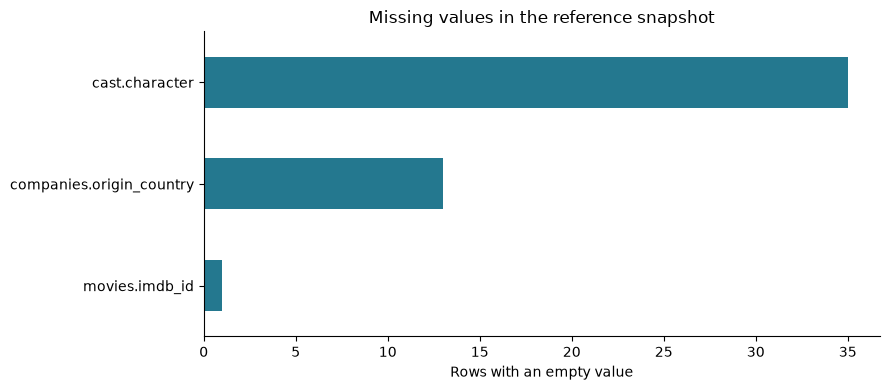

,table,exact duplicate rows
0,movies,0
1,genres,0
2,companies,0
3,countries,0
4,languages,0
5,movie_genres,0
6,movie_companies,0
7,movie_countries,0
8,movie_languages,0
9,cast,0


In [23]:
missing = pd.DataFrame([
 {'table': n, 'field': c, 'missing': int(d[c].str.strip().eq('').sum()), 'rows': len(d)}
 for n, d in tables.items() for c in d.columns])
missing['percent'] = (100 * missing['missing'] / missing['rows'].replace(0, float('nan'))).round(1)
display(missing.loc[missing.missing.gt(0)].sort_values('missing', ascending=False))
nonzero_missing = missing.loc[missing.missing.gt(0)].copy()
if len(nonzero_missing):
    nonzero_missing['label'] = nonzero_missing.table + '.' + nonzero_missing.field
    ax = nonzero_missing.set_index('label')['missing'].sort_values().plot.barh(color='#24788f')
    ax.set(title='Missing values in the reference snapshot', xlabel='Rows with an empty value', ylabel='')
    plt.tight_layout(); plt.show()
else:
    print('No empty fields here; future collections must still support missing values.')
display(pd.DataFrame([{'table': n, 'exact duplicate rows': int(d.duplicated().sum())}
                      for n, d in tables.items()]))

In [24]:
entity_keys = {'movies': 'id', 'genres': 'id', 'companies': 'id',
               'countries': 'country_code', 'languages': 'language_code'}
display(pd.DataFrame([{'table': n, 'key': key, 'unique': tables[n][key].is_unique,
                      'empty keys': int(tables[n][key].eq('').sum())}
                     for n, key in entity_keys.items()]))
duplicate_titles = movies.loc[movies.title.duplicated(keep=False), ['id', 'title', 'release_date']]
print('Rows sharing a title:', len(duplicate_titles))
display(duplicate_titles)
references = [
 ('movie_genres', 'genre_id', 'genres', 'id'),
 ('movie_companies', 'company_id', 'companies', 'id'),
 ('movie_countries', 'country_code', 'countries', 'country_code'),
 ('movie_languages', 'language_code', 'languages', 'language_code'),
 ('companies', 'origin_country', 'countries', 'country_code'),
 ('movies', 'original_language', 'languages', 'language_code')]
references += [(n, 'movie_id', 'movies', 'id') for n in
               ['movie_genres', 'movie_companies', 'movie_countries', 'movie_languages', 'cast', 'crew']]
reference_checks = []
for source, field, target, key in references:
    unresolved = set(tables[source][field]) - {''} - set(tables[target][key])
    reference_checks.append({'from': f'{source}.{field}', 'to': f'{target}.{key}',
                             'unresolved IDs': ', '.join(sorted(unresolved)), 'count': len(unresolved)})
display(pd.DataFrame(reference_checks))

,table,key,unique,empty keys
0,movies,id,True,0
1,genres,id,True,0
2,companies,id,True,0
3,countries,country_code,True,0
4,languages,language_code,True,0


Rows sharing a title: 0


,id,title,release_date


,from,to,unresolved IDs,count
0,movie_genres.genre_id,genres.id,,0
1,movie_companies.company_id,companies.id,,0
2,movie_countries.country_code,countries.country_code,,0
3,movie_languages.language_code,languages.language_code,,0
4,companies.origin_country,countries.country_code,,0
5,movies.original_language,languages.language_code,,0
6,movie_genres.movie_id,movies.id,,0
7,movie_companies.movie_id,movies.id,,0
8,movie_countries.movie_id,movies.id,,0
9,movie_languages.movie_id,movies.id,,0


**Interpretation:** even if titles are unique here, this does not prove they are
safe identifiers for all movies. Use /movie/{id} and /person/{id}. The paths
prevent movie ID 123 from colliding with person ID 123.

Pay attention to company countries and original languages. The reference builds
country labels from movie production-country lists, and language labels from
spoken-language lists. A company country or original language can therefore
lack a lookup row. Preserve its code and obtain a label from evidence, or keep
an explicitly incomplete resource. Do not invent a name.

Exact duplicate relationships can be removed after inspection. Conflicting
records with the same entity ID need a resolution policy.

## 5. Genres: why two tables?

genres.csv answers **what is genre 18 called?** movie_genres.csv answers
**which movies have genre 18?** A movie can have several genres, and a genre
can describe many movies: a **many-to-many relationship**.

Each association becomes an RDF edge. We do not need genre1/genre2/genre3 columns.

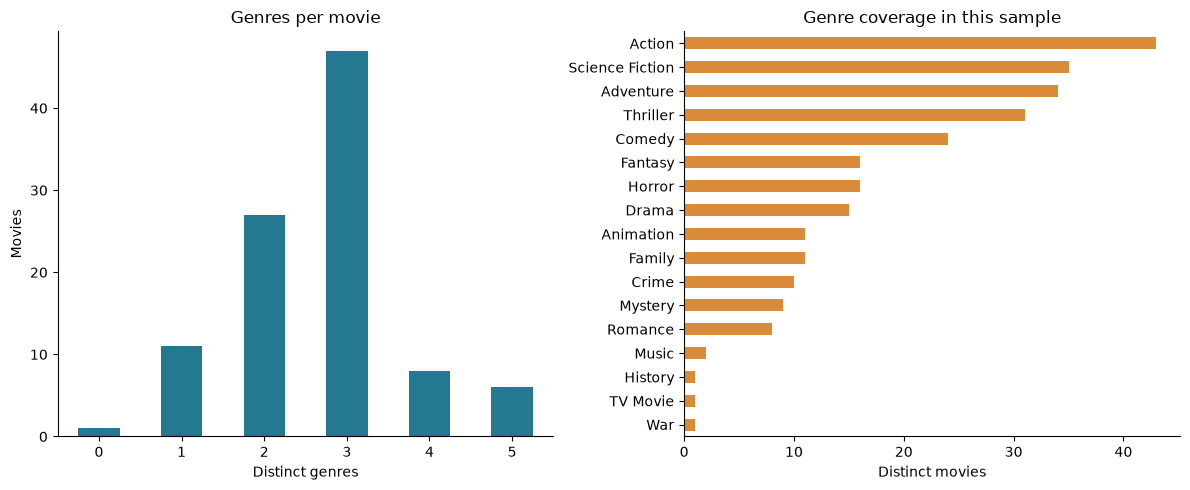

Movies with multiple genres: 88


In [25]:
genre_links = tables['movie_genres'].drop_duplicates()
genres_per_movie = genre_links.groupby('movie_id').genre_id.nunique().reindex(movies.id, fill_value=0)
genre_frequency = genre_links.groupby('genre_id').movie_id.nunique().rename('movies').reset_index()
genre_frequency = genre_frequency.merge(tables['genres'], left_on='genre_id', right_on='id')
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
genres_per_movie.value_counts().sort_index().plot.bar(ax=axes[0], color='#24788f', rot=0)
axes[0].set(title='Genres per movie', xlabel='Distinct genres', ylabel='Movies')
genre_frequency.set_index('name')['movies'].sort_values().plot.barh(ax=axes[1], color='#d98b39')
axes[1].set(title='Genre coverage in this sample', xlabel='Distinct movies', ylabel='')
plt.tight_layout(); plt.show()
print('Movies with multiple genres:', int(genres_per_movie.gt(1).sum()))

**Decision:** propose kg:Genre as a class and Drama as an instance, retaining
schema:genre as the relationship. We do not need a new Movie subclass for every
genre to answer our questions. No exactly-one genre restriction is appropriate.

This is a small vocabulary correction to the reference's schema:Genre.
Schema.org documents DefinedTerm, Text, and URL as values of
[genre](https://schema.org/genre); our local Genre could specialize DefinedTerm.

## 6. People: one identity across movies and jobs

Repeating a person's name in credits must not create a new person each time.
Combine cast and crew IDs to recognize the same person. An actor can also
direct, so Actor and Director should not be disjoint categories.

The plot measures appearances **in our retained sample**, not a person's whole
career. The first ten cast members do not represent a film's full cast.

Person IDs with conflicting names: 0


,person_id,person_name


Distinct people: 985


,person_id,person_name
16,84833,Zach Cregger
162,124747,Pierre Coffin
587,15277,Jon Favreau


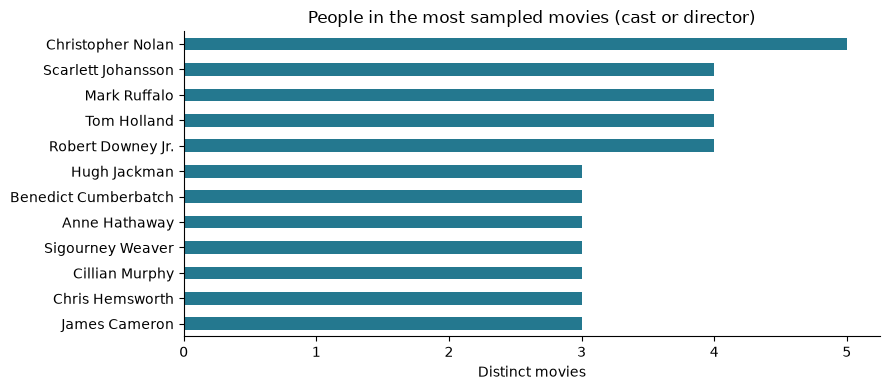

,cast rows,distinct directors
count,100.000000,100.000000
mean,9.750000,1.100000
std,1.104399,0.333333
min,3.000000,1.000000
25%,10.000000,1.000000
50%,10.000000,1.000000
75%,10.000000,1.000000
max,10.000000,3.000000


Crew jobs: ['Director']
Movies with multiple directors: 9


In [26]:
participation = pd.concat([
 cast[['movie_id', 'person_id', 'person_name']].assign(kind='cast'),
 crew[['movie_id', 'person_id', 'person_name']].assign(kind='director')], ignore_index=True)
people = participation[['person_id', 'person_name']].drop_duplicates()
name_conflicts = people.groupby('person_id').person_name.nunique()
print('Person IDs with conflicting names:', int(name_conflicts.gt(1).sum()))
display(people.loc[people.person_id.isin(name_conflicts[name_conflicts.gt(1)].index)])
print('Distinct people:', participation.person_id.nunique())
both_ids = set(cast.person_id) & set(crew.person_id)
display(people.loc[people.person_id.isin(both_ids)].drop_duplicates('person_id').head(15))
counts = participation.groupby('person_id').movie_id.nunique().rename('movies').reset_index()
counts = counts.merge(people.drop_duplicates('person_id'), on='person_id').sort_values('movies', ascending=False)
ax = counts.head(12).sort_values('movies').set_index('person_name')['movies'].plot.barh(color='#24788f')
ax.set(title='People in the most sampled movies (cast or director)', xlabel='Distinct movies', ylabel='')
plt.tight_layout(); plt.show()
cast_counts = cast.groupby('movie_id').size().reindex(movies.id, fill_value=0)
director_counts = crew.groupby('movie_id').person_id.nunique().reindex(movies.id, fill_value=0)
display(pd.DataFrame({'cast rows': cast_counts, 'distinct directors': director_counts}).describe())
print('Crew jobs:', sorted(crew.job.unique()))
print('Movies with multiple directors:', int(director_counts.gt(1).sum()))

### Character and position belong to a Role

Putting characterName directly on Person loses which film it belongs to.
Use a participation node:

~~~text
Movie ──actor──> Person                       (convenient direct link)
Movie ──actor──> Role ──actor──> Person        (participation details)
                 ├──characterName──> text
                 └──position───────> integer
~~~

The reference uses **blank nodes** for roles: resources without global URIs.
A blank node is not a missing value. Named role URIs are also possible.
We keep the reference's shape for now.

A character string may contain “Character A / Character B”. Preserve the source
string initially; splitting it into character entities needs a separate decision.

In [27]:
cast_film_counts = cast.groupby('person_id').movie_id.nunique().sort_values(ascending=False)
role_person_id = cast_film_counts.index[0]
role_examples = cast.loc[cast.person_id.eq(role_person_id)].merge(
    movies[['id', 'title']], left_on='movie_id', right_on='id', validate='many_to_one')
display(role_examples[['movie_id', 'title', 'person_id', 'person_name', 'character', 'order']])
print('One shared person URI:', 'https://example.org/person/' + role_person_id)
print('Each row retains its own movie-specific character and cast position.')

,movie_id,title,person_id,person_name,character,order
0,299534,Avengers: Endgame,1245,Scarlett Johansson,Natasha Romanoff / Black Widow,4
1,299536,Avengers: Infinity War,1245,Scarlett Johansson,Natasha Romanoff / Black Widow,5
2,24428,The Avengers,1245,Scarlett Johansson,Natasha Romanoff / Black Widow,4
3,1234821,Jurassic World Rebirth,1245,Scarlett Johansson,Zora Bennett,0


One shared person URI: https://example.org/person/1245
Each row retains its own movie-specific character and cast position.


## 7. Dates and runtime: values have types and units

CSV stores text. Future RDF values should express their meaning:
an xsd:date for a release date, and xsd:duration such as PT145M for 145 minutes.
The number 145 alone does not say whether it measures minutes, votes, or money.

We convert a separate analysis view and report failed conversions. The date is
the source's recorded movie release date, not necessarily every regional date.
Future-dated records deserve review, but are not automatically wrong.

,id,title,release_date,runtime


Nonempty unparseable dates: 0
Zero runtimes (review separately): 2


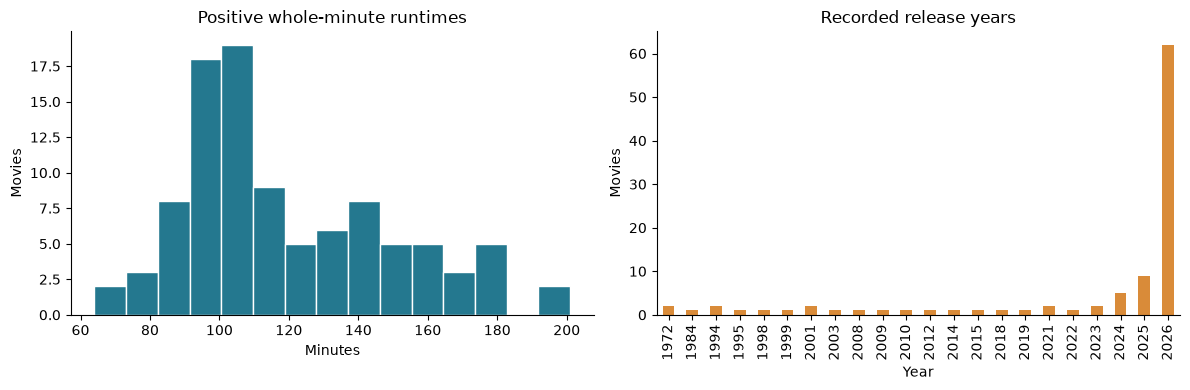

In [28]:
analysis = movies.copy()
analysis['date'] = pd.to_datetime(movies.release_date, format='%Y-%m-%d', errors='coerce')
for col in ['runtime', 'vote_average', 'vote_count']:
    analysis[col] = pd.to_numeric(movies[col], errors='coerce')
invalid_dates = movies.release_date.ne('') & analysis.date.isna()
invalid_runtime = movies.runtime.ne('') & (analysis.runtime.isna() | analysis.runtime.lt(0) |
                                         analysis.runtime.mod(1).ne(0))
display(movies.loc[invalid_dates | invalid_runtime, ['id', 'title', 'release_date', 'runtime']])
print('Nonempty unparseable dates:', int(invalid_dates.sum()))
print('Zero runtimes (review separately):', int(analysis.runtime.eq(0).sum()))
valid_runtime = analysis.runtime.where(analysis.runtime.gt(0) & analysis.runtime.mod(1).eq(0)).dropna()
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(valid_runtime, bins=15, color='#24788f', edgecolor='white')
axes[0].set(title='Positive whole-minute runtimes', xlabel='Minutes', ylabel='Movies')
years = analysis.date.dt.year.dropna().astype(int).value_counts().sort_index()
years.plot.bar(ax=axes[1], color='#d98b39')
axes[1].set(title='Recorded release years', xlabel='Year', ylabel='Movies')
plt.tight_layout(); plt.show()

**Interpretation:** the distributions describe sample coverage and review items.
They do not define the permissible runtime or release year of every Movie.
Declare intended datatypes; validate bad source values separately.

## 8. Ratings: keep a score and its evidence together

A score of 9 from 2 votes and a score of 9 from 20,000 votes give different
evidence. Group average and count in one AggregateRating linked to a movie.
The reference uses a blank node for this group.

Our model has one current summary per movie **in this snapshot**. Historical
ratings would need collection times and a different design. Zero votes does
not support a meaningful average even if the source stores a numeric zero.

,id,title,vote_average,vote_count


Rows with zero votes: 2


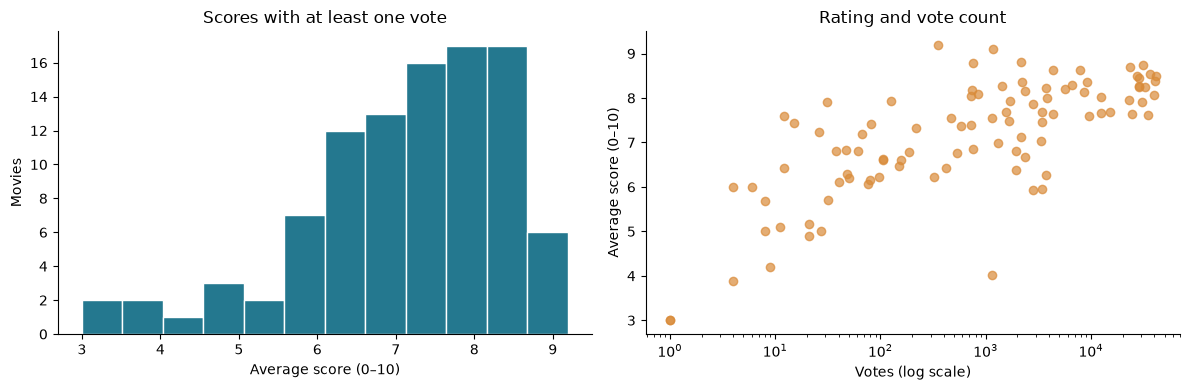

,id,title,vote_average,vote_count
48,1560520,Batman: Knightfall Part 1: Knightfall,9.190,352
32,980431,Avatar Aang: The Last Airbender,9.100,1166
62,1311031,Demon Slayer: Kimetsu no Yaiba Infinity Castle,8.800,2159
25,1621552,Facing El Chapo,8.777,761
43,278,The Shawshank Redemption,8.731,31367
63,238,The Godfather,8.687,23604
28,687163,Project Hail Mary,8.640,7870
80,936075,Michael,8.634,4382
66,155,The Dark Knight,8.535,36743
96,122,The Lord of the Rings: The Return of the King,8.506,27372


In [29]:
valid_rating = analysis.vote_average.between(0, 10) & analysis.vote_count.ge(0) & analysis.vote_count.mod(1).eq(0)
has_votes = valid_rating & analysis.vote_count.gt(0)
display(movies.loc[~valid_rating, ['id', 'title', 'vote_average', 'vote_count']])
print('Rows with zero votes:', int(analysis.vote_count.eq(0).sum()))
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(analysis.loc[has_votes, 'vote_average'], bins=12, color='#24788f', edgecolor='white')
axes[0].set(title='Scores with at least one vote', xlabel='Average score (0–10)', ylabel='Movies')
axes[1].scatter(analysis.loc[has_votes, 'vote_count'], analysis.loc[has_votes, 'vote_average'],
                color='#d98b39', alpha=.7)
axes[1].set_xscale('log')
axes[1].set(title='Rating and vote count', xlabel='Votes (log scale)', ylabel='Average score (0–10)')
plt.tight_layout(); plt.show()
display(analysis.loc[has_votes & analysis.vote_count.ge(100),
                     ['id', 'title', 'vote_average', 'vote_count']]
        .sort_values(['vote_average', 'vote_count'], ascending=False).head(10))

## 9. Company country is not movie country

~~~text
Movie ──productionCompany──> Organization ──location──> Country
Movie ──countryOfOrigin──────────────────────────────> Country
~~~

The first path uses companies.origin_country, mapped to schema:location to
stay close to the reference. The second uses movie_countries. Neither proves
a filming location. A co-production can have multiple companies and countries.

In [30]:
company_path = tables['movie_companies'].merge(tables['companies'], left_on='company_id',
                                              right_on='id', validate='many_to_one')
company_sets = company_path.loc[company_path.origin_country.ne('')].groupby('movie_id').origin_country.agg(set)
movie_sets = tables['movie_countries'].groupby('movie_id').country_code.agg(set)
country_comparison = movies[['id', 'title']].copy()
country_comparison['company country codes'] = country_comparison.id.map(
    lambda x: ', '.join(sorted(company_sets.get(x, set()))))
country_comparison['movie country codes'] = country_comparison.id.map(
    lambda x: ', '.join(sorted(movie_sets.get(x, set()))))
country_differences = country_comparison.loc[
    country_comparison['company country codes'].ne(country_comparison['movie country codes'])]
print('Movies whose two recorded country sets differ:', len(country_differences))
display(country_differences.head(12))
display(company_path.loc[company_path.movie_id.eq(example_id),
                         ['movie_id', 'company_id', 'name', 'origin_country']])

Movies whose two recorded country sets differ: 10


,id,title,company country codes,movie country codes
26,1506560,Clash of the Thundermans,US,"CA, US"
30,1127384,Deep Water,"AU, ES, US","AU, CN, ES, UA, US"
37,1599993,Animals,,DO
39,264980,Loves of a French Pussycat,,DE
40,1419406,The Shadow's Edge,CN,"CN, HK"
54,1405742,Portal to Hell,"CA, US",US
69,1180894,Under Your Feet,ES,"AR, ES"
71,27205,Inception,US,"GB, US"
76,1641580,The Last Assassins,,CA
91,1386238,Black Gold,,AR


,movie_id,company_id,name,origin_country
0,969681,420,Marvel Studios,US
1,969681,5,Columbia Pictures,US
2,969681,84041,Pascal Pictures,US
3,969681,22213,TSG Entertainment,US


**OWL inference later:** movie → company → country can imply
kg:productionCountry, a shortcut for company-associated country. It must not
replace the movie's own origin relationship. Even when the sets match, their
meanings remain different.

### Original and spoken languages also differ

movies.original_language records an original-language code; movie_languages
comes from a spoken-language list. The reference puts both into schema:inLanguage.
For our spoken-language question Q9, reserve that predicate for spoken languages
and propose kg:originalLanguage for the original one. Carry this small change
into the later ontology and transformer.

In [31]:
spoken_sets = tables['movie_languages'].groupby('movie_id').language_code.agg(set)
spoken_counts = movies.id.map(lambda x: len(spoken_sets.get(x, set())))
language_review = movies[['id', 'title', 'original_language']].copy()
language_review['spoken language codes'] = movies.id.map(lambda x: ', '.join(sorted(spoken_sets.get(x, set()))))
original_not_spoken = movies.original_language.ne('') & pd.Series(
    [r.original_language not in spoken_sets.get(r.id, set()) for r in movies.itertuples()], index=movies.index)
print('Movies with multiple spoken languages:', int(spoken_counts.gt(1).sum()))
print('Original-language code absent from spoken list:', int(original_not_spoken.sum()))
display(language_review.loc[original_not_spoken].head(10))

Movies with multiple spoken languages: 29
Original-language code absent from spoken list: 3


,id,title,original_language,spoken language codes
13,1386315,The Runner,en,
19,1323244,Rage of Stars,en,
46,1156869,Blaze of Love,en,


## 10. Put the proposed graph together

The arrows connect resources. Literal values are not separate entity classes.
Role and AggregateRating remain resources even when represented by blank nodes.
This diagram describes the proposed model, not an already implemented OWL file.

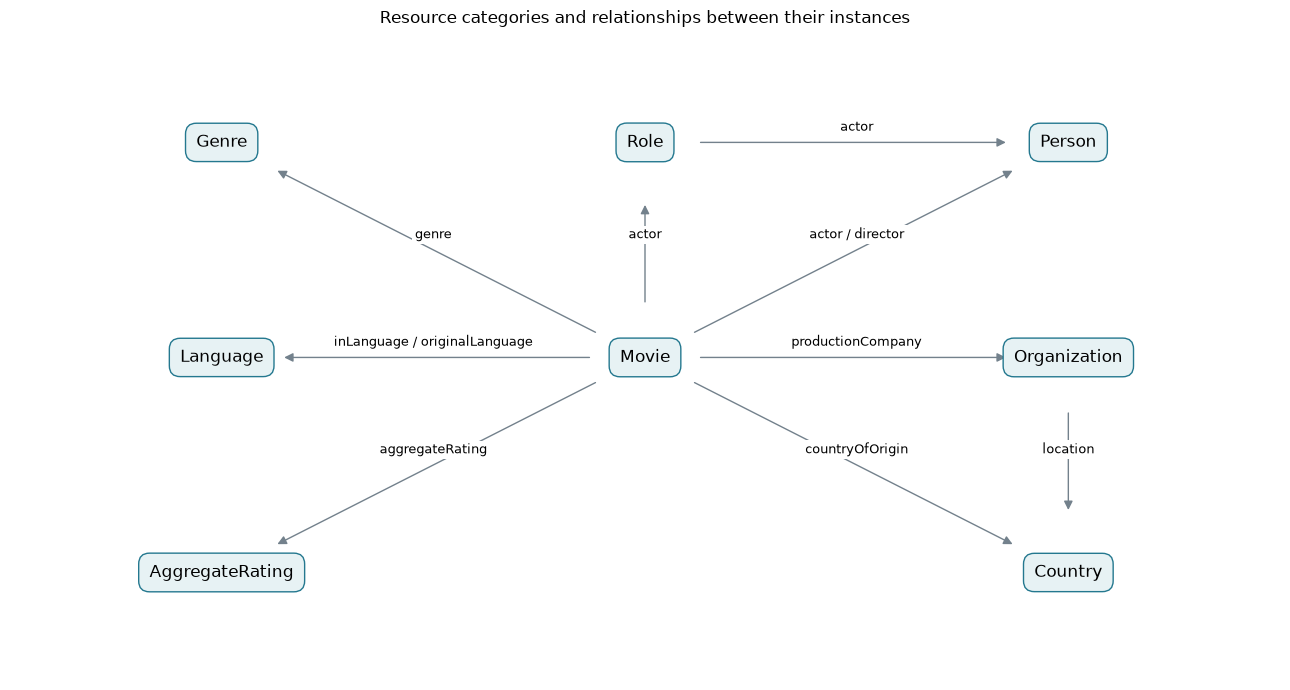

In [32]:
from matplotlib.patches import FancyArrowPatch
fig, ax = plt.subplots(figsize=(13, 7))
positions = {'Movie': (0, 0), 'Person': (4, 2.4), 'Role': (0, 2.4),
             'Genre': (-4, 2.4), 'Organization': (4, 0), 'Country': (4, -2.4),
             'Language': (-4, 0), 'AggregateRating': (-4, -2.4)}
edges = [('Movie', 'Person', 'actor / director'), ('Movie', 'Role', 'actor'),
         ('Role', 'Person', 'actor'), ('Movie', 'Genre', 'genre'),
         ('Movie', 'Organization', 'productionCompany'), ('Organization', 'Country', 'location'),
         ('Movie', 'Country', 'countryOfOrigin'), ('Movie', 'Language', 'inLanguage / originalLanguage'),
         ('Movie', 'AggregateRating', 'aggregateRating')]
for source, target, label in edges:
    x1, y1 = positions[source]; x2, y2 = positions[target]
    ax.add_patch(FancyArrowPatch((x1, y1), (x2, y2), arrowstyle='-|>', mutation_scale=13,
                                shrinkA=40, shrinkB=45, color='#73818c'))
    ax.text((x1+x2)/2, (y1+y2)/2 + .13, label, fontsize=9, ha='center',
            bbox=dict(facecolor='white', edgecolor='none', pad=2))
for label, (x, y) in positions.items():
    ax.text(x, y, label, ha='center', va='center', fontsize=12,
            bbox=dict(boxstyle='round,pad=.65', facecolor='#e7f2f4', edgecolor='#24788f'))
ax.set(xlim=(-6, 6), ylim=(-3.6, 3.5)); ax.axis('off')
ax.set_title('Resource categories and relationships between their instances', pad=15)
plt.tight_layout(); plt.show()

### Translate one path into RDF sentences

The next cell prints an illustrative Turtle fragment for the selected movie's
first cast row. It writes no RDF file. The letter **a** means rdf:type: the
resource belongs to that class. A semicolon reuses the subject, and square
brackets introduce a blank node. This is an excerpt, not a complete transformer.

In [33]:
actor = cast.loc[cast.movie_id.eq(example_id)].iloc[0]
quote = lambda value: json.dumps(value, ensure_ascii=False)
example_turtle = f"""@prefix schema: <https://schema.org/> .
@prefix xsd: <http://www.w3.org/2001/XMLSchema#> .

<https://example.org/movie/{example_id}> a schema:Movie ;
    schema:name {quote(example_movie['title'])} ;
    schema:actor <https://example.org/person/{actor['person_id']}> ;
    schema:actor [ a schema:Role ;
        schema:actor <https://example.org/person/{actor['person_id']}> ;
        schema:characterName {quote(actor['character'])} ;
        schema:position {quote(actor['order'])}^^xsd:integer ] .

<https://example.org/person/{actor['person_id']}> a schema:Person ;
    schema:name {quote(actor['person_name'])} .
"""
print(example_turtle)

@prefix schema: <https://schema.org/> .
@prefix xsd: <http://www.w3.org/2001/XMLSchema#> .

<https://example.org/movie/969681> a schema:Movie ;
    schema:name "Spider-Man: Brand New Day" ;
    schema:actor <https://example.org/person/1136406> ;
    schema:actor [ a schema:Role ;
        schema:actor <https://example.org/person/1136406> ;
        schema:characterName "Peter Parker / Spider-Man" ;
        schema:position "0"^^xsd:integer ] .

<https://example.org/person/1136406> a schema:Person ;
    schema:name "Tom Holland" .



## 11. Constraints: data checks versus OWL inference

“This file contains 100 movies” is a sample fact. “Keep ten actors” is a
collection policy. Neither is a universal definition of Movie.

| Statement | Kind | How to use it |
|---|---|---|
| Movie IDs must be nonempty and unique in the table | Data quality | Check before exporting |
| Foreign keys should resolve | Data quality | Report missing targets; repair from evidence |
| Votes are nonnegative integers; rating is 0–10 | Data quality | Check numeric input |
| Movie is a CreativeWork | OWL subclass axiom | Infer superclass membership |
| director has domain Movie and range Person | OWL typing | Infer types from property use; not an SQL foreign-key check |
| directedMovie is inverse of director | OWL inverse axiom | Derive the reverse relationship |
| Movie→company→country implies a shortcut | OWL property chain | Derive kg:productionCountry |
| Movie and Person are disjoint | OWL disjointness | One individual cannot consistently belong to both |
| Each Role has one actor in our representation | Modeling restriction + data check | Later express qualified cardinality; check rows separately |
| A movie has at most one rating summary here | Snapshot design | Do not generalize to historical ratings |

**Open-world example:** if a movie lacks a name triple, OWL does not conclude
it has no name. A minimum-name restriction is not a missing-field check.
Use Python checks (or later SHACL) for required data.

**Functional-property example:** if one subject has two object URIs for a
functional property, OWL may infer that the objects are the same thing.
It does not simply reject a second row. The reference's functional and inverse-
functional IMDb-page property needs this care.

**Domain trap:** declaring schema:identifier to have domain Movie and using
it on people would infer that those people are movies. The reference's actor
predicate is used on Movie and Role, so a Movie-only domain would also be wrong.

OWL-RL implements a rule-oriented subset. An OWL declaration does not guarantee
every consequence is implemented by a chosen engine. We will test our selected
axioms later. See the [W3C OWL 2 Primer](https://www.w3.org/TR/owl2-primer/).

## 12. How TMDB responses become these 11 CSVs

We now work backwards from the snapshot. The reference requests /movie/popular,
then /movie/{id} and /movie/{id}/credits. Movie details contain scalar values
and nested lists; credits contain cast and crew lists. See TMDB's
[details](https://developer.themoviedb.org/reference/movie-details) and
[credits](https://developer.themoviedb.org/reference/movie-credits) documentation.

The next cell creates a **teaching reconstruction** of the retained information.
It is not an original API response. Uncollected fields, omitted actors, and
other crew jobs cannot be recovered. The preview shows just two cast entries
to make the nesting readable. Identifiers here remain CSV strings.

In [34]:
def linked_records(relation, lookup, foreign_key, key):
    return tables[relation].loc[tables[relation].movie_id.eq(example_id)].merge(
        tables[lookup], left_on=foreign_key, right_on=key, validate='many_to_one')
genre_rows = linked_records('movie_genres', 'genres', 'genre_id', 'id')
company_rows = linked_records('movie_companies', 'companies', 'company_id', 'id')
country_rows = linked_records('movie_countries', 'countries', 'country_code', 'country_code')
language_rows = linked_records('movie_languages', 'languages', 'language_code', 'language_code')
teaching_details = {field: example_movie[field] for field in movies.columns}
teaching_details.update({
 'genres': genre_rows[['id', 'name']].to_dict('records'),
 'production_companies': company_rows[['id', 'name', 'origin_country']].to_dict('records'),
 'production_countries': country_rows.rename(columns={'country_code': 'iso_3166_1'})[
     ['iso_3166_1', 'name']].to_dict('records'),
 'spoken_languages': language_rows.rename(columns={'language_code': 'iso_639_1'})[
     ['iso_639_1', 'name']].to_dict('records')})
teaching_credits = {
 'cast': cast.loc[cast.movie_id.eq(example_id)].rename(
     columns={'person_id': 'id', 'person_name': 'name'})[['id', 'name', 'character', 'order']].to_dict('records'),
 'crew': crew.loc[crew.movie_id.eq(example_id)].rename(
     columns={'person_id': 'id', 'person_name': 'name'})[['id', 'name', 'job']].to_dict('records')}
print(json.dumps({'details': teaching_details,
                  'credits_preview': {'cast': teaching_credits['cast'][:2],
                                      'crew': teaching_credits['crew']}}, indent=2, ensure_ascii=False))

{
  "details": {
    "id": "969681",
    "imdb_id": "tt22084616",
    "title": "Spider-Man: Brand New Day",
    "overview": "Fighting crime full-time as Spider-Man in a world that doesn't remember him—and the pressure of seeing his old friends move on without him—sparks a change in Peter Parker he may not have the power to control. But that transformation might also be the only thing that can stop a shocking new threat to the city and those he loves - a powerful villain no one can even see.",
    "original_language": "en",
    "release_date": "2026-07-29",
    "runtime": "145",
    "vote_average": "7.86",
    "vote_count": "2795",
    "genres": [
      {
        "id": "878",
        "name": "Science Fiction"
      },
      {
        "id": "28",
        "name": "Action"
      },
      {
        "id": "12",
        "name": "Adventure"
      }
    ],
    "production_companies": [
      {
        "id": "420",
        "name": "Marvel Studios",
        "origin_country": "US"
      },
      {

### A split you can reproduce by hand

For each genre object in a movie's nested genre list:

1. Store its ID and name in a dictionary keyed by genre ID. Across movies,
   reuse the entry, checking for conflicting names.
2. Add the (movie_id, genre_id) pair to a relationship set.

The dictionary becomes genres.csv; the set becomes movie_genres.csv.
Repeat the pattern for companies, countries, and languages.

In [35]:
# Demonstration only: rows for one movie in memory, no files written.
demo_genres = {}
demo_movie_genres = set()
for genre in teaching_details['genres']:
    demo_genres[genre['id']] = {'id': genre['id'], 'name': genre['name']}
    demo_movie_genres.add((teaching_details['id'], genre['id']))
display(Markdown('**Rows destined for genres.csv**'))
display(pd.DataFrame(demo_genres.values()))
display(Markdown('**Rows destined for movie_genres.csv**'))
display(pd.DataFrame(sorted(demo_movie_genres), columns=['movie_id', 'genre_id']))

**Rows destined for genres.csv**

,id,name
0,878,Science Fiction
1,28,Action
2,12,Adventure


**Rows destined for movie_genres.csv**

,movie_id,genre_id
0,969681,12
1,969681,28
2,969681,878


### Complete future exporter recipe

| Response content | Output | Operation |
|---|---|---|
| Nine scalar movie fields explained above | movies.csv | One row per distinct movie ID |
| details.genres | genres.csv + movie_genres.csv | Deduplicate genre entities; add movie–genre pairs |
| details.production_companies | companies.csv + movie_companies.csv | Deduplicate companies; retain origin_country; add pairs |
| details.production_countries | countries.csv + movie_countries.csv | Rename iso_3166_1 to country_code; add pairs |
| details.spoken_languages | languages.csv + movie_languages.csv | Rename iso_639_1 to language_code; retain name; add pairs |
| credits.cast | cast.csv | First ten source-ordered credits; rename person fields; keep character/order |
| credits.crew where job is Director | crew.csv | Keep all directors; rename person fields; keep job |

After accumulation, ensure lookup coverage for company countries and original
languages. Keep unknown values empty, preserve Unicode, write UTF-8 headers
exactly as shown, deduplicate relationship pairs, and check IDs before saving.
Do not replace a missing country with a guess.

Why no people table? To match the reference, retain person IDs/names in credits;
the later transformer creates one Person resource per ID. A separate people
table is optional and not necessary for this layout.

CSVs are intermediate data, not OWL. A relationship row becomes an edge, a
credit row can become a Role resource, and two movie columns can become an
AggregateRating resource.

## 13. Connect questions back to tables

| Question | Table path | What the graph needs |
|---|---|---|
| Q1: dated films | movies | Typed dates |
| Q2: people who act and direct | cast ↔ crew on person_id | Shared person identity |
| Q3: actors and characters | movies → cast | Role with character and position |
| Q4: highly rated Drama | movies → movie_genres → genres | Rating and genre relationships |
| Q5: date + actor + genre | movies → cast and movie_genres → genres | Several paths from one movie |
| Q6: pairs sharing films | cast joined to cast on movie_id | Count distinct movies for each ordered pair |
| Q7: directors with multiple films | crew → movies | Group by person ID |
| Q8: company countries | movie_companies → companies → countries | Company-country path |
| Q9: multiple spoken languages | movie_languages | Distinct language relationships |
| Q10: external facts | Later links → external dataset | Verified identity links |

Q10 cannot be answered by these files alone. Requirements analysis has
identified work for the future linking stage.

## 14. Observation → modeling decision

The final table combines measured observations with explicit design choices.
Evidence describes this snapshot; decisions describe our proposed representation.

In [36]:
decisions = [
 (f'{movies.id.nunique()} distinct movie IDs in {len(movies)} rows',
  'One schema:Movie resource per source ID', 'Do not identify films by title'),
 (f'{len(duplicate_titles)} rows share a title',
  'Use IDs even when a sample has no duplicate titles', 'Sample uniqueness is not universal'),
 (f'{int(genres_per_movie.gt(1).sum())} movies have several genres',
  'Movie → schema:genre → kg:Genre instance', 'No exactly-one genre restriction'),
 (f'{int(counts.movies.gt(1).sum())} people occur in multiple sampled movies',
  'Reuse Person URIs', 'Names are labels, not keys'),
 (f'{len(both_ids)} IDs occur in cast and director credits',
  'Both relationships can target the same Person', 'Do not make Actor and Director disjoint'),
 ('Character and position occur in a movie-specific cast row',
  'Create schema:Role participation nodes', 'Do not attach these globally to Person'),
 (f'{int(director_counts.gt(1).sum())} movies have multiple directors',
  'Allow several director edges', 'Do not infer one-director cardinality'),
 (f'{int(missing.missing.sum())} empty source cells',
  'Omit unknown facts and report completeness', 'Unknown is not false'),
 ('Runtime is minutes; release date is a date string',
  'Use xsd:duration and xsd:date after validation', 'Sample min/max are not ontology limits'),
 ('Average and vote count describe one summary',
  'One AggregateRating per movie in this snapshot', 'History would require another design'),
 (f'{len(country_differences)} movies have differing recorded company/movie country sets',
  'Keep company location and movie origin separate', 'Neither proves filming location'),
 (f'{int(spoken_counts.gt(1).sum())} movies have multiple spoken languages',
  'Separate spoken and original language properties', 'Small change from reference needed for Q9'),
 ('No Wikidata/DBpedia identity assertions in these CSVs',
  'Link with evidence in a later stage', 'Similar titles alone do not prove identity')]
display(pd.DataFrame(decisions, columns=['Observation', 'Modeling decision', 'Caution / scope']))

,Observation,Modeling decision,Caution / scope
0,100 distinct movie IDs in 100 rows,One schema:Movie resource per source ID,Do not identify films by title
1,0 rows share a title,Use IDs even when a sample has no duplicate titles,Sample uniqueness is not universal
2,88 movies have several genres,Movie → schema:genre → kg:Genre instance,No exactly-one genre restriction
3,75 people occur in multiple sampled movies,Reuse Person URIs,"Names are labels, not keys"
4,3 IDs occur in cast and director credits,Both relationships can target the same Person,Do not make Actor and Director disjoint
5,Character and position occur in a movie-specific cast row,Create schema:Role participation nodes,Do not attach these globally to Person
6,9 movies have multiple directors,Allow several director edges,Do not infer one-director cardinality
7,49 empty source cells,Omit unknown facts and report completeness,Unknown is not false
8,Runtime is minutes; release date is a date string,Use xsd:duration and xsd:date after validation,Sample min/max are not ontology limits
9,Average and vote count describe one summary,One AggregateRating per movie in this snapshot,History would require another design


### Check your understanding

1. Is Drama a class or an instance here? **An instance of Genre.**
2. Why is characterName not on Person? **It depends on participation in a movie.**
3. Does a movie–genre row need its own class? **Usually no; it becomes an edge.**
4. Does missing runtime mean zero minutes? **No; preserve the uncertainty.**
5. Can one person act and direct? **Yes; reuse the person URI.**
6. Does a company's country prove filming location? **No.**
7. Does OWL detect every missing title cell? **No; use a separate data check.**
8. Can we answer Q10 now? **No; verified external links come later.**

**Next lesson:** write class/property declarations and the inverse/property-chain
axioms, check them on a tiny example, then implement collection and transformation
against this table contract.